# Speed Dating — Clustering

We cluster speed-dating participants to find natural personality types. The target
`match` is never used to build clusters — only afterwards, to interpret them.

Analysis strategy: an initial clustering splits the data almost entirely by **gender**
(the strongest natural division). Since that is expected and uninformative, we then
cluster **within each gender separately** to find personality types that are not merely
a proxy for sex.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import joblib
from scipy import stats

from sklearn.cluster import KMeans, AgglomerativeClustering, Birch, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', None)

print("Libraries loaded.")

Libraries loaded.


In [2]:
X_full = pd.read_csv('../data/processed/X_scaled.csv')
X_no_outcome = pd.read_csv('../data/processed/X_scaled_no_outcome.csv')
X_unscaled = pd.read_csv('../data/processed/X_unscaled.csv')
meta = pd.read_csv('../data/processed/metadata.csv')

with open('../models/preprocessing_config.json') as f:
    config = json.load(f)
BLOCKS = config['blocks']

INTERESTS = BLOCKS['interests']
IMPORTANCE = BLOCKS['importance']
SELF = BLOCKS['self_rating']

print(f"X_no_outcome: {X_no_outcome.shape}")
print(f"match rate: {meta['match'].mean():.3f}, persons: {meta['person_id'].nunique()}")

X_no_outcome: (8378, 81)
match rate: 0.165, persons: 549


## Feature set 1: person profile

We start with attributes describing the participant — interests, preferences, self-ratings,
and demographics — excluding partner attributes and outcome. First we find how many clusters
the data supports.

**Finding:** the strongest split (k=2, highest silhouette) is almost perfectly gender.
Match rate is identical across the two clusters — the split carries no information about
outcome, only sex. This is expected but uninformative. To find real personality types,
we cluster within each gender separately.

In [3]:
person_profile = (INTERESTS + IMPORTANCE + SELF + BLOCKS['gender']
                  + BLOCKS['race'] + BLOCKS['field'] + BLOCKS['demographics']
                  + BLOCKS['same_values'] + BLOCKS['expectations'])
person_profile = [c for c in person_profile if c in X_no_outcome.columns]

print(f"person_profile: {len(person_profile)} attributes")

person_profile: 54 attributes


In [4]:
X = X_no_outcome[person_profile].values
idx = np.random.RandomState(RANDOM_STATE).choice(len(X), 2000, replace=False)

print("Silhouette by k (k-means):")
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    lbl = km.fit_predict(X)
    s = silhouette_score(X[idx], lbl[idx])
    print(f"  k={k}: silhouette={s:.3f}")

Silhouette by k (k-means):
  k=2: silhouette=0.134
  k=3: silhouette=0.100
  k=4: silhouette=0.105
  k=5: silhouette=0.080
  k=6: silhouette=0.080


In [5]:
km2 = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
labels2 = km2.fit_predict(X)

print("k=2 — gender split per cluster (share male):")
print(pd.Series(X_no_outcome['gender_male'].values).groupby(labels2).mean().round(3))
print()
print("Match rate per cluster:")
print(pd.Series(meta['match'].values).groupby(labels2).mean().round(3))

k=2 — gender split per cluster (share male):
0    0.999
1   -1.001
dtype: float64

Match rate per cluster:
0    0.165
1    0.165
dtype: float64


**Finding:** the strongest split (k=2, highest silhouette) is almost perfectly gender.
Match rate is identical across the two clusters — the split carries no information about
outcome, only sex. This is expected but uninformative. To find real personality types,
we cluster within each gender separately.

## A data-quality artifact

Clustering with k=4 on the full profile produces a small odd cluster (63 rows). Before
trusting any clustering, we check what defines it.

In [6]:
km4_art = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
labels_art = km4_art.fit_predict(X)

small = pd.Series(labels_art).value_counts().idxmin()
print(f"Smallest cluster: {(labels_art == small).sum()} rows")
print()

Xp = X_no_outcome[person_profile]
diffs = (Xp[labels_art == small].mean() - Xp[labels_art != small].mean()).sort_values()
print("What defines this cluster (top deviations):")
print(diffs.tail(5).round(2))

Smallest cluster: 63 rows

What defines this cluster (top deviations):
expected_happy_with_sd_people    0.30
age                              0.66
d_age                            2.92
field_Unknown                    3.34
race_Unknown                     4.73
dtype: float64


**Finding:** the cluster is defined by `race_Unknown` and `field_Unknown` — records where
these attributes were missing, not a personality type. This is an artifact of missing-data
indicators, not real structure. We remove the Unknown columns from the feature set.

In [7]:
person_profile = [c for c in person_profile if 'Unknown' not in c]
print(f"person_profile (cleaned): {len(person_profile)} attributes")

person_profile (cleaned): 52 attributes


## Clustering within each gender

Since gender dominates, we split the data by sex and cluster each group separately.
Gender and race columns are dropped here — within a single sex they add noise, and we want
types defined by personality, not demographics. For each gender we find its own optimal
number of clusters.

In [8]:
within_gender_cols = [c for c in person_profile
                      if c not in BLOCKS['gender'] and c not in BLOCKS['race']]

is_male = X_no_outcome['gender_male'] > 0
X_men = X_no_outcome.loc[is_male, within_gender_cols].values
X_women = X_no_outcome.loc[~is_male, within_gender_cols].values

print(f"Attributes used within gender: {len(within_gender_cols)}")
print(f"Men: {X_men.shape[0]} rows, Women: {X_women.shape[0]} rows")

Attributes used within gender: 46
Men: 4194 rows, Women: 4184 rows


In [9]:
def silhouette_by_k(X, label):
    idx = np.random.RandomState(RANDOM_STATE).choice(len(X), min(2000, len(X)), replace=False)
    print(f"{label}:")
    for k in range(2, 6):
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        lbl = km.fit_predict(X)
        s = silhouette_score(X[idx], lbl[idx])
        print(f"  k={k}: silhouette={s:.3f}")
    print()

silhouette_by_k(X_men, "Men")
silhouette_by_k(X_women, "Women")

Men:
  k=2: silhouette=0.071
  k=3: silhouette=0.075
  k=4: silhouette=0.071
  k=5: silhouette=0.082

Women:
  k=2: silhouette=0.103
  k=3: silhouette=0.093
  k=4: silhouette=0.091
  k=5: silhouette=0.077



**Finding:** women show a clear peak at k=2 — two natural types. Men show a flat, low
silhouette across all k — no natural subdivision; they form one homogeneous group. This
asymmetry (women more varied than men) is itself a finding. We therefore use **three types**:
one male group and two female groups.

In [10]:
km_women = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
women_labels = km_women.fit_predict(X_women)

final_labels = np.full(len(X_no_outcome), -1)
final_labels[is_male.values] = 0
final_labels[~is_male.values] = women_labels + 1

print("Final cluster sizes:")
print(pd.Series(final_labels).value_counts().sort_index())
print()
print("Gender split (share male):")
print(pd.Series(X_no_outcome['gender_male'].values).groupby(final_labels).mean().round(2))
print()
print("Match rate per cluster:")
print(pd.Series(meta['match'].values).groupby(final_labels).mean().round(3))

Final cluster sizes:
0    4194
1    2572
2    1612
Name: count, dtype: int64

Gender split (share male):
0    1.0
1   -1.0
2   -1.0
dtype: float64

Match rate per cluster:
0    0.165
1    0.180
2    0.140
dtype: float64


In [11]:
interpret_cols = ['age', 'attractive', 'sincere', 'intelligence', 'funny', 'ambition',
                  'sports', 'tvsports', 'exercise', 'gaming', 'clubbing',
                  'art', 'museums', 'theater', 'reading', 'music', 'yoga', 'hiking',
                  'attractive_important', 'ambtition_important', 'shared_interests_important']
interpret_cols = [c for c in interpret_cols if c in X_unscaled.columns]

profile = pd.DataFrame(index=interpret_cols)
for c in [0, 1, 2]:
    profile[f'C{c}'] = X_unscaled.loc[final_labels == c, interpret_cols].mean()
profile['overall'] = X_unscaled[interpret_cols].mean()

pd.set_option('display.float_format', '{:.2f}'.format)
print("Cluster profiles (original units):")
print(profile)

Cluster profiles (original units):
                              C0    C1    C2  overall
age                        26.63 26.90 24.98    26.40
attractive                  6.95  7.11  7.37     7.08
sincere                     8.13  8.38  8.59     8.29
intelligence                7.52  7.75  8.11     7.70
funny                       8.48  8.22  8.47     8.40
ambition                    7.53  7.38  8.02     7.58
sports                      7.02  5.51  6.25     6.41
tvsports                    4.98  3.87  4.59     4.57
exercise                    6.04  6.11  6.94     6.23
gaming                      4.40  3.03  3.68     3.84
clubbing                    5.60  6.07  5.64     5.75
art                         6.22  7.33  7.08     6.73
museums                     6.56  7.46  7.39     6.99
theater                     6.09  7.31  7.79     6.79
reading                     7.44  8.08  7.60     7.67
music                       7.72  7.97  8.05     7.86
yoga                        3.71  4.99  4.99   

**Interpretation:**
- **C0 (men):** highest on sports and `attractive_important`, lowest on culture and on
  valuing ambition — sport and looks-oriented.
- **C1 (women):** high on art, museums, reading, and shared interests; lowest on valuing
  a partner's looks — culture and connection-oriented.
- **C2 (women):** youngest, highest self-ratings (attractiveness, intelligence, ambition),
  most active — confident and driven.

In [12]:
cluster_names = {
    0: 'Sport & looks-oriented (M)',
    1: 'Culture & connection (F)',
    2: 'Confident & driven (F)'
}
for c, name in cluster_names.items():
    print(f"C{c}: {name} — {(final_labels == c).sum()} rows")

C0: Sport & looks-oriented (M) — 4194 rows
C1: Culture & connection (F) — 2572 rows
C2: Confident & driven (F) — 1612 rows


In [13]:
print("Match rate per type:")
for c in [0, 1, 2]:
    mask = final_labels == c
    print(f"  {cluster_names[c]:<28} n={mask.sum():>4}  match={meta.loc[mask, 'match'].mean():.3f}")
print(f"\n  Overall: {meta['match'].mean():.3f}")

chi2, p, _, _ = stats.chi2_contingency(pd.crosstab(final_labels, meta['match']))
print(f"\nChi-square: chi2={chi2:.2f}, p={p:.4f}")
print("Significant difference." if p < 0.05 else "Not significant.")

Match rate per type:
  Sport & looks-oriented (M)   n=4194  match=0.165
  Culture & connection (F)     n=2572  match=0.180
  Confident & driven (F)       n=1612  match=0.140

  Overall: 0.165

Chi-square: chi2=11.64, p=0.0030
Significant difference.


**Match finding:** the three types differ significantly in match rate (p ≈ 0.003), even
though clustering never used the outcome. The confident, driven female type has the *lowest*
match rate, while the culture- and connection-oriented type has the highest — suggesting
high self-regard and selectivity may reduce matching on short encounters.

Variance explained: 22.6%


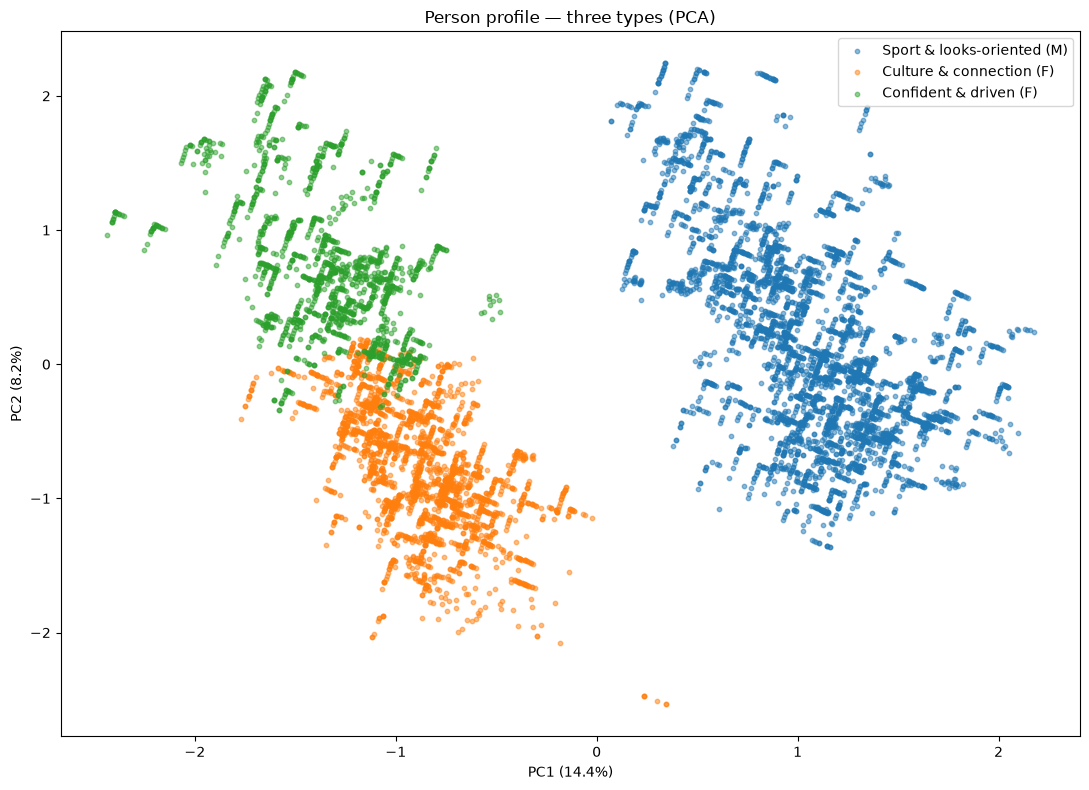

In [14]:
X = X_no_outcome[person_profile].values

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)
print(f"Variance explained: {pca.explained_variance_ratio_[:2].sum():.1%}")

plt.figure(figsize=(11, 8))
for c in [0, 1, 2]:
    mask = final_labels == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=10, alpha=0.5, label=cluster_names[c])
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('Person profile — three types (PCA)')
plt.legend()
plt.tight_layout()
plt.show()

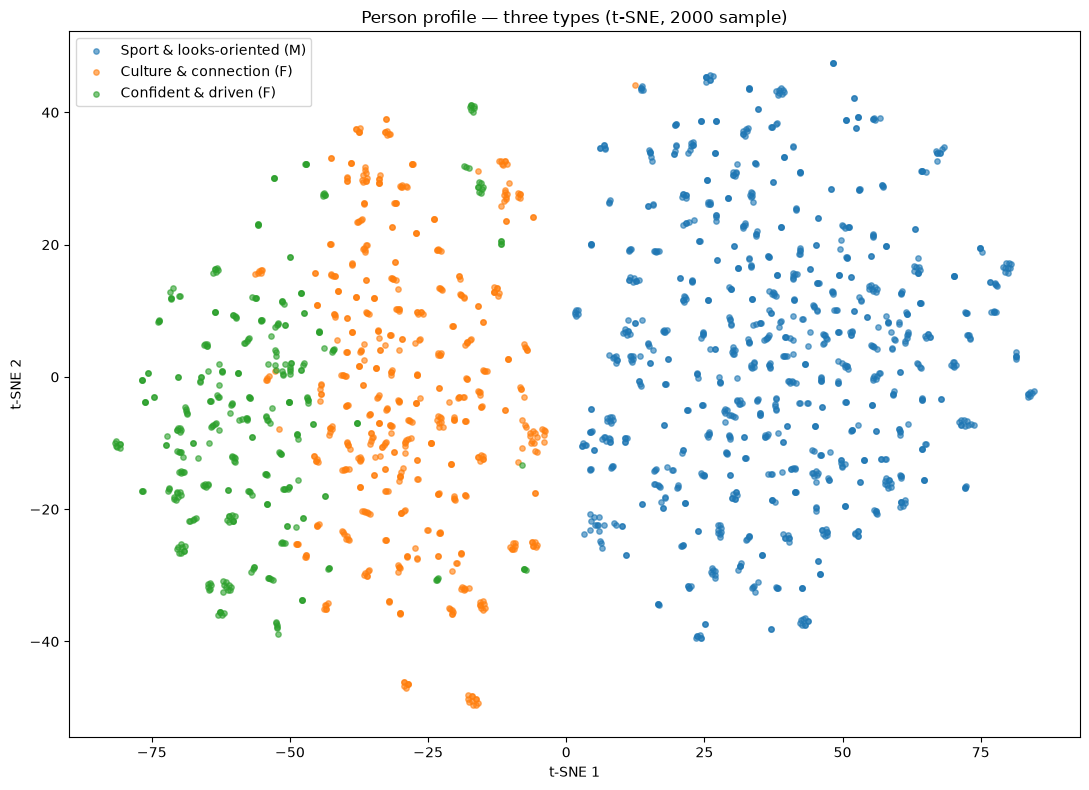

In [15]:
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X), 2000, replace=False)
X_sample = X[sample_idx]
labels_sample = final_labels[sample_idx]

tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30)
X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(11, 8))
for c in [0, 1, 2]:
    mask = labels_sample == c
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=15, alpha=0.6, label=cluster_names[c])
plt.title('Person profile — three types (t-SNE, 2000 sample)')
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2')
plt.legend()
plt.tight_layout()
plt.show()

Both projections show the same structure: gender separates the data along the main axis
(men on one side, the two female types on the other), with softer boundaries between the
two female types. The 2D projection captures only ~20% of the variance, so the overlap on
screen overstates the actual overlap in the full 52-dimensional space.

## Feature set 2: preferences and self-image

Using what people say they want in a partner (`*_important`) and how they rate themselves.
Unlike person profile, this set has no single dominant axis like gender, which makes it a
fair ground for comparing clustering algorithms. We first establish the k-means solution,
then compare five algorithms in detail.

Preferences set: 11 attributes
Silhouette by k:
  k=2: silhouette=0.143
  k=3: silhouette=0.142
  k=4: silhouette=0.084
  k=5: silhouette=0.087
  k=6: silhouette=0.104


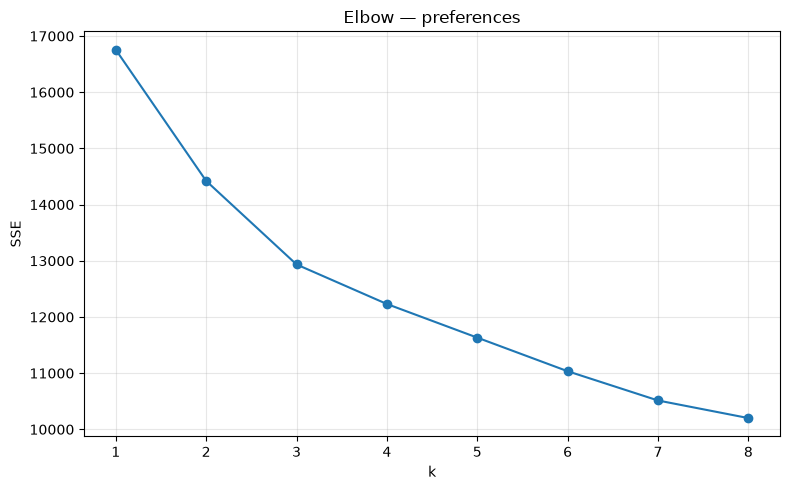

In [16]:
pref_cols = IMPORTANCE + SELF
X_pref = X_no_outcome[pref_cols].values
idx = np.random.RandomState(RANDOM_STATE).choice(len(X_pref), 2000, replace=False)

print(f"Preferences set: {len(pref_cols)} attributes")
print("Silhouette by k:")
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    lbl = km.fit_predict(X_pref)
    s = silhouette_score(X_pref[idx], lbl[idx])
    print(f"  k={k}: silhouette={s:.3f}")

sse = []
for k in range(1, 9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_pref)
    sse.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 9), sse, 'o-')
plt.xlabel('k'); plt.ylabel('SSE'); plt.title('Elbow — preferences')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Choosing k:** silhouette is nearly identical for k=2 and k=3 (≈0.143), while the elbow
bends at k=3. We choose **k=3** — the metrics support it and it gives a richer, interpretable
partition.

In [17]:
km_pref = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
pref_labels = km_pref.fit_predict(X_pref)

print("Sizes:", pd.Series(pref_labels).value_counts().sort_index().tolist())
print("Gender split (share male):")
print(pd.Series(X_no_outcome['gender_male'].values).groupby(pref_labels).mean().round(2))
print()

pref_profile = pd.DataFrame(index=pref_cols)
for c in [0, 1, 2]:
    pref_profile[f'C{c}'] = X_unscaled.loc[pref_labels == c, pref_cols].mean()
pref_profile['overall'] = X_unscaled[pref_cols].mean()
print(pref_profile.round(2))

Sizes: [1317, 2852, 4209]
Gender split (share male):
0    0.48
1    0.04
2   -0.17
dtype: float64

                              C0    C1    C2  overall
attractive_important       44.09 19.32 17.87    22.49
sincere_important           9.31 20.02 18.15    17.40
intellicence_important     16.80 21.70 20.39    20.27
funny_important            17.77 17.55 17.29    17.46
ambtition_important         5.58  8.66 13.57    10.64
shared_interests_important  7.09 12.75 12.73    11.85
attractive                  7.75  6.04  7.58     7.08
sincere                     7.52  7.96  8.76     8.29
intelligence                8.44  6.57  8.24     7.70
funny                       8.50  7.76  8.80     8.40
ambition                    7.98  6.13  8.43     7.58


In [18]:
pref_names = {
    0: 'Looks-driven',
    1: 'Character-seekers',
    2: 'Ambition-valuers'
}
for c, name in pref_names.items():
    print(f"C{c}: {name} — {(pref_labels == c).sum()} rows, "
          f"match={meta.loc[pref_labels == c, 'match'].mean():.3f}")

C0: Looks-driven — 1317 rows, match=0.174
C1: Character-seekers — 2852 rows, match=0.154
C2: Ambition-valuers — 4209 rows, match=0.169


In [19]:
print("Preferences — match rate per cluster:")
for c in [0, 1, 2]:
    mask = pref_labels == c
    print(f"  {pref_names[c]:<18} n={mask.sum():>4}  match={meta.loc[mask, 'match'].mean():.3f}")
print(f"\n  Overall: {meta['match'].mean():.3f}")

chi2, p, _, _ = stats.chi2_contingency(pd.crosstab(pref_labels, meta['match']))
print(f"\nChi-square: chi2={chi2:.2f}, p={p:.4f}")
print("Significant." if p < 0.05 else "Not significant.")

Preferences — match rate per cluster:
  Looks-driven       n=1317  match=0.174
  Character-seekers  n=2852  match=0.154
  Ambition-valuers   n=4209  match=0.169

  Overall: 0.165

Chi-square: chi2=3.60, p=0.1650
Not significant.


**Match finding:** the preference groups do not differ significantly in match rate (p ≈ 0.17). Numerically the looks-driven group is highest (0.174) and character-seekers lowest (0.154), but with p ≈ 0.17 this gap is not reliable — it could be chance. This contrasts with the person-profile types, which did differ significantly (p ≈ 0.003). In this sample, then, matching is associated with the person-based clusterings — who a person is — but not with the preference-based one — what they say they are looking for.

# How different algorithms see this structure

The preferences set has no dominant axis like gender, which makes it a fair testing ground:
different clustering algorithms rest on different assumptions, and those assumptions may lead
to different results.

## Hierarchical (agglomerative) clustering

Agglomerative clustering starts with each point as its own cluster and repeatedly merges the
two closest ones. We keep k=3 (chosen earlier for this feature set) and select the algorithm's
own key parameter — the **linkage**, i.e. how distance between clusters is measured:
`ward` (minimizes within-cluster variance), `complete` (farthest pair), or `average`
(mean pairwise distance). We compare them by silhouette.

In [20]:
idx = np.random.RandomState(RANDOM_STATE).choice(len(X_pref), 2000, replace=False)

print("Silhouette by linkage (k=3):")
for link in ['ward', 'complete', 'average']:
    lbl = AgglomerativeClustering(n_clusters=3, linkage=link).fit_predict(X_pref)
    s = silhouette_score(X_pref[idx], lbl[idx])
    print(f"  {link:<10} silhouette={s:.3f}")

Silhouette by linkage (k=3):
  ward       silhouette=0.131
  complete   silhouette=0.231
  average    silhouette=0.368


In [21]:
print("Cluster sizes by linkage (k=3):")
for link in ['ward', 'complete', 'average']:
    lbl = AgglomerativeClustering(n_clusters=3, linkage=link).fit_predict(X_pref)
    sizes = pd.Series(lbl).value_counts().sort_index().tolist()
    print(f"  {link:<10} {sizes}")

Cluster sizes by linkage (k=3):
  ward       [4671, 2705, 1002]
  complete   [7763, 307, 308]
  average    [8343, 19, 16]


**Choosing linkage:** `average` and `complete` have higher silhouette (0.37 and 0.23) than
`ward` (0.13) — but their cluster sizes reveal why: they isolate a handful of outliers
(`average`: 8343 / 19 / 16) rather than partitioning the data. `ward` gives the only
balanced split (4671 / 2705 / 1002), comparable to k-means. We select **ward**, choosing
interpretability over a silhouette score inflated by a degenerate partition.

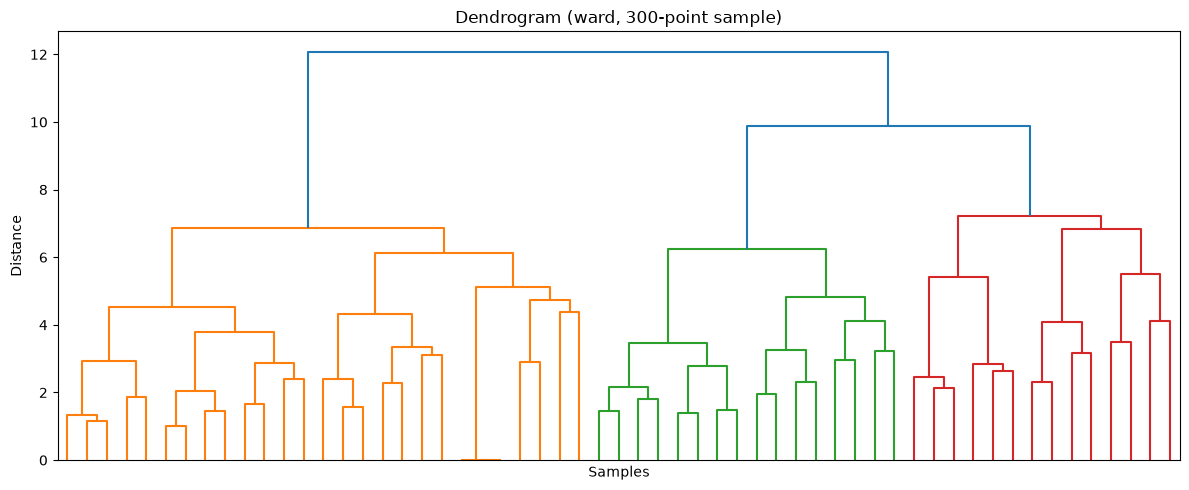

In [22]:
from scipy.cluster.hierarchy import dendrogram, linkage as scipy_linkage

sample = X_pref[np.random.RandomState(RANDOM_STATE).choice(len(X_pref), 300, replace=False)]
Z = scipy_linkage(sample, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode='level', p=5, no_labels=True)
plt.title('Dendrogram (ward, 300-point sample)')
plt.xlabel('Samples'); plt.ylabel('Distance')
plt.tight_layout()
plt.show()

## Gaussian Mixture

GMM models the data as a mix of Gaussian components with soft assignments. Its key parameter
is the **covariance type**, controlling component shape: `spherical`, `diag`, `tied`, or
`full`. We select it with the Bayesian Information Criterion (BIC) — lower is better.

In [23]:
print("BIC by covariance type (k=3):")
for cov in ['spherical', 'diag', 'tied', 'full']:
    g = GaussianMixture(n_components=3, covariance_type=cov, random_state=RANDOM_STATE)
    g.fit(X_pref)
    print(f"  {cov:<10} BIC={g.bic(X_pref):.0f}")

BIC by covariance type (k=3):
  spherical  BIC=88240
  diag       BIC=80150
  tied       BIC=51875
  full       BIC=-24331


**Choosing covariance:** BIC clearly favours `full` (the only negative value, far below the
others), so each component gets its own unconstrained elliptical shape. We use `full`.

BIC by number of components (full covariance):
  k=1: BIC=56583
  k=2: BIC=-8967
  k=3: BIC=-24331
  k=4: BIC=-27388
  k=5: BIC=-29697
  k=6: BIC=-31422


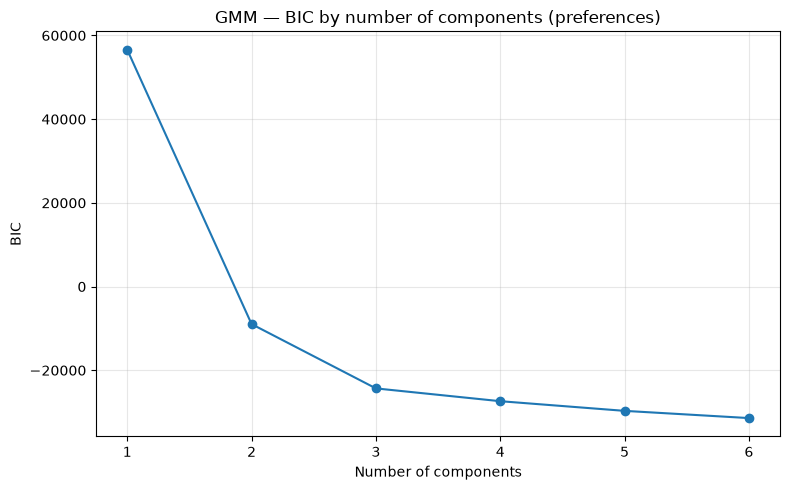

In [24]:
print("BIC by number of components (full covariance):")
bics = []
for k in range(1, 7):
    g = GaussianMixture(n_components=k, covariance_type='full', random_state=RANDOM_STATE)
    g.fit(X_pref)
    bics.append(g.bic(X_pref))
    print(f"  k={k}: BIC={bics[-1]:.0f}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, 7), bics, 'o-')
plt.xlabel('Number of components'); plt.ylabel('BIC')
plt.title('GMM — BIC by number of components (preferences)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**BIC by components:** the curve bends sharply at k=3 and flattens afterwards — BIC supports
three components, agreeing with the silhouette and elbow analysis. Unlike some feature sets
where BIC keeps decreasing without bound, here it confirms k=3 as a natural choice.

## BIRCH

BIRCH builds a tree of cluster summaries, suitable for large datasets. Its key parameter is
the **threshold** — the radius below which points merge into the same sub-cluster. A smaller
threshold makes finer sub-clusters. We compare a few values by silhouette at k=3.

In [25]:
idx = np.random.RandomState(RANDOM_STATE).choice(len(X_pref), 2000, replace=False)

print("Silhouette and sizes by threshold (k=3):")
for th in [0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0, 1.5]:
    lbl = Birch(n_clusters=3, threshold=th).fit_predict(X_pref)
    if len(set(lbl)) < 2:
        print(f"  threshold={th}: only {len(set(lbl))} cluster — skipped")
        continue
    s = silhouette_score(X_pref[idx], lbl[idx])
    sizes = pd.Series(lbl).value_counts().sort_index().tolist()
    balance = min(sizes) / max(sizes)
    print(f"  threshold={th}: silhouette={s:.3f}, balance={balance:.2f}, sizes={sizes}")

Silhouette and sizes by threshold (k=3):
  threshold=0.1: silhouette=0.141, balance=0.13, sizes=[2907, 647, 4824]
  threshold=0.2: silhouette=0.091, balance=0.54, sizes=[2002, 2643, 3733]
  threshold=0.3: silhouette=0.094, balance=0.12, sizes=[3883, 4024, 471]
  threshold=0.4: silhouette=0.111, balance=0.10, sizes=[5348, 522, 2508]
  threshold=0.5: silhouette=0.179, balance=0.12, sizes=[6687, 884, 807]
  threshold=0.7: silhouette=0.065, balance=0.20, sizes=[3164, 853, 4361]
  threshold=1.0: silhouette=0.139, balance=0.10, sizes=[1729, 6060, 589]
  threshold=1.5: silhouette=0.208, balance=0.02, sizes=[787, 136, 7455]


**Choosing threshold:** no threshold gives balanced clusters — BIRCH always isolates one
dominant group. The higher silhouette at 0.5 and 1.5 is misleading (at 1.5, one cluster holds
7455 of 8378 points). We use **threshold=0.2**, the most balanced split (2002 / 2643 / 3733),
prioritising a meaningful partition over an inflated score.

## DBSCAN

DBSCAN groups points in dense regions and labels the rest as noise. It takes no fixed number
of clusters — instead two parameters: **eps** (neighbourhood radius) and **min_samples**
(points needed for a dense region). To choose eps we use the **k-distance graph**: for a given
min_samples, we compute each point's distance to its min_samples-th nearest neighbour (using
NearestNeighbors), sort these, and look for an elbow where distance rises sharply. A clear
elbow marks a natural eps; a smooth curve means no natural density boundary exists.

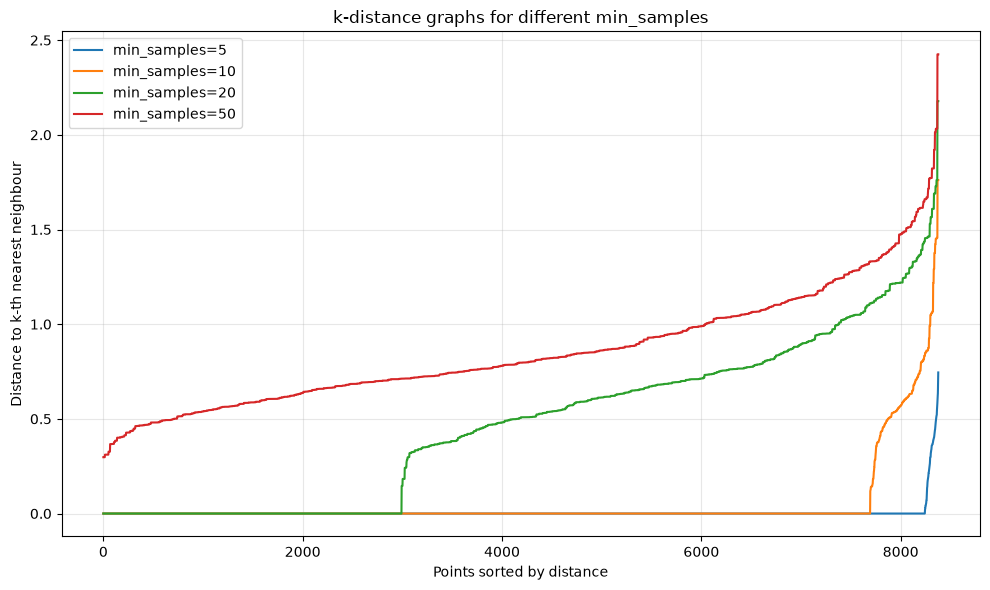

In [26]:
from sklearn.neighbors import NearestNeighbors

plt.figure(figsize=(10, 6))
for ms in [5, 10, 20, 50]:
    nn = NearestNeighbors(n_neighbors=ms).fit(X_pref)
    distances, _ = nn.kneighbors(X_pref)
    kth_dist = np.sort(distances[:, -1])
    plt.plot(kth_dist, label=f'min_samples={ms}')

plt.xlabel('Points sorted by distance')
plt.ylabel('Distance to k-th nearest neighbour')
plt.title('k-distance graphs for different min_samples')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Reading the graph:** for small min_samples (5, 10) most points lie at distance ≈ 0 from
their k-th neighbour — the preferences set has several discrete-valued attributes, so many
participants share identical answers. For larger min_samples (20, 50) the curve is smooth and
rises gradually. In neither case is there a sharp elbow: there is no distance at which a
natural density boundary appears. This already suggests DBSCAN will struggle here. We verify
it directly by running DBSCAN across a range of both parameters.

In [27]:
print("DBSCAN outcomes across parameters:")
print(f"{'min_samples':>11} {'eps':>5} {'clusters':>9} {'noise':>7} {'largest':>8}")
for ms in [5, 10, 20]:
    for eps in [0.5, 1.0, 1.5]:
        lbl = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_pref)
        n_cl = len(set(lbl)) - (1 if -1 in lbl else 0)
        n_noise = (lbl == -1).sum()
        largest = pd.Series(lbl[lbl != -1]).value_counts().max() if n_cl > 0 else 0
        print(f"{ms:>11} {eps:>5} {n_cl:>9} {n_noise:>7} {largest:>8}")

DBSCAN outcomes across parameters:
min_samples   eps  clusters   noise  largest
          5   0.5       436       8     1455
          5   1.0       105       0     6676
          5   1.5        10       0     8203
         10   0.5       377     459     1439
         10   1.0        94      81     6676
         10   1.5         9       9     8203
         20   0.5       128    4099     1375
         20   1.0        32     961     6676
         20   1.5         4      78     8203


**Result:** no combination gives a meaningful partition. Small eps fragments the data into
hundreds of clusters; large eps collapses almost everything into one (8203 of 8378 points at
eps=1.5). Across the whole parameter grid DBSCAN either shatters or merges — never three
balanced groups. This confirms the k-distance graph: with no density gaps, DBSCAN is unsuited
to this data, regardless of parameters.

## Summary: five algorithms on the preferences set

Bringing the five algorithms together, each with its chosen parameter, compared by silhouette
and agreement with k-means (ARI).

In [28]:
idx = np.random.RandomState(RANDOM_STATE).choice(len(X_pref), 2000, replace=False)

km_lbl = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10).fit_predict(X_pref)
agg_lbl = AgglomerativeClustering(n_clusters=3, linkage='ward').fit_predict(X_pref)
gmm_lbl = GaussianMixture(n_components=3, covariance_type='full', random_state=RANDOM_STATE).fit_predict(X_pref)
birch_lbl = Birch(n_clusters=3, threshold=0.2).fit_predict(X_pref)
db_lbl = DBSCAN(eps=1.0, min_samples=10).fit_predict(X_pref)

print(f"{'algorithm':<14} {'silhouette':>11} {'ARI':>8} {'clusters':>9}")
for name, lbl in [('k-means', km_lbl), ('hierarchical', agg_lbl),
                  ('gmm', gmm_lbl), ('birch', birch_lbl), ('dbscan', db_lbl)]:
    n_cl = len(set(lbl)) - (1 if -1 in lbl else 0)
    s = silhouette_score(X_pref[idx], lbl[idx]) if n_cl > 1 else float('nan')
    ari = adjusted_rand_score(km_lbl, lbl)
    print(f"{name:<14} {s:>11.3f} {ari:>8.3f} {n_cl:>9}")

algorithm       silhouette      ARI  clusters
k-means              0.142    1.000         3
hierarchical         0.131    0.569         3
gmm                  0.030    0.080         3
birch                0.091    0.421         3
dbscan               0.074    0.152        94


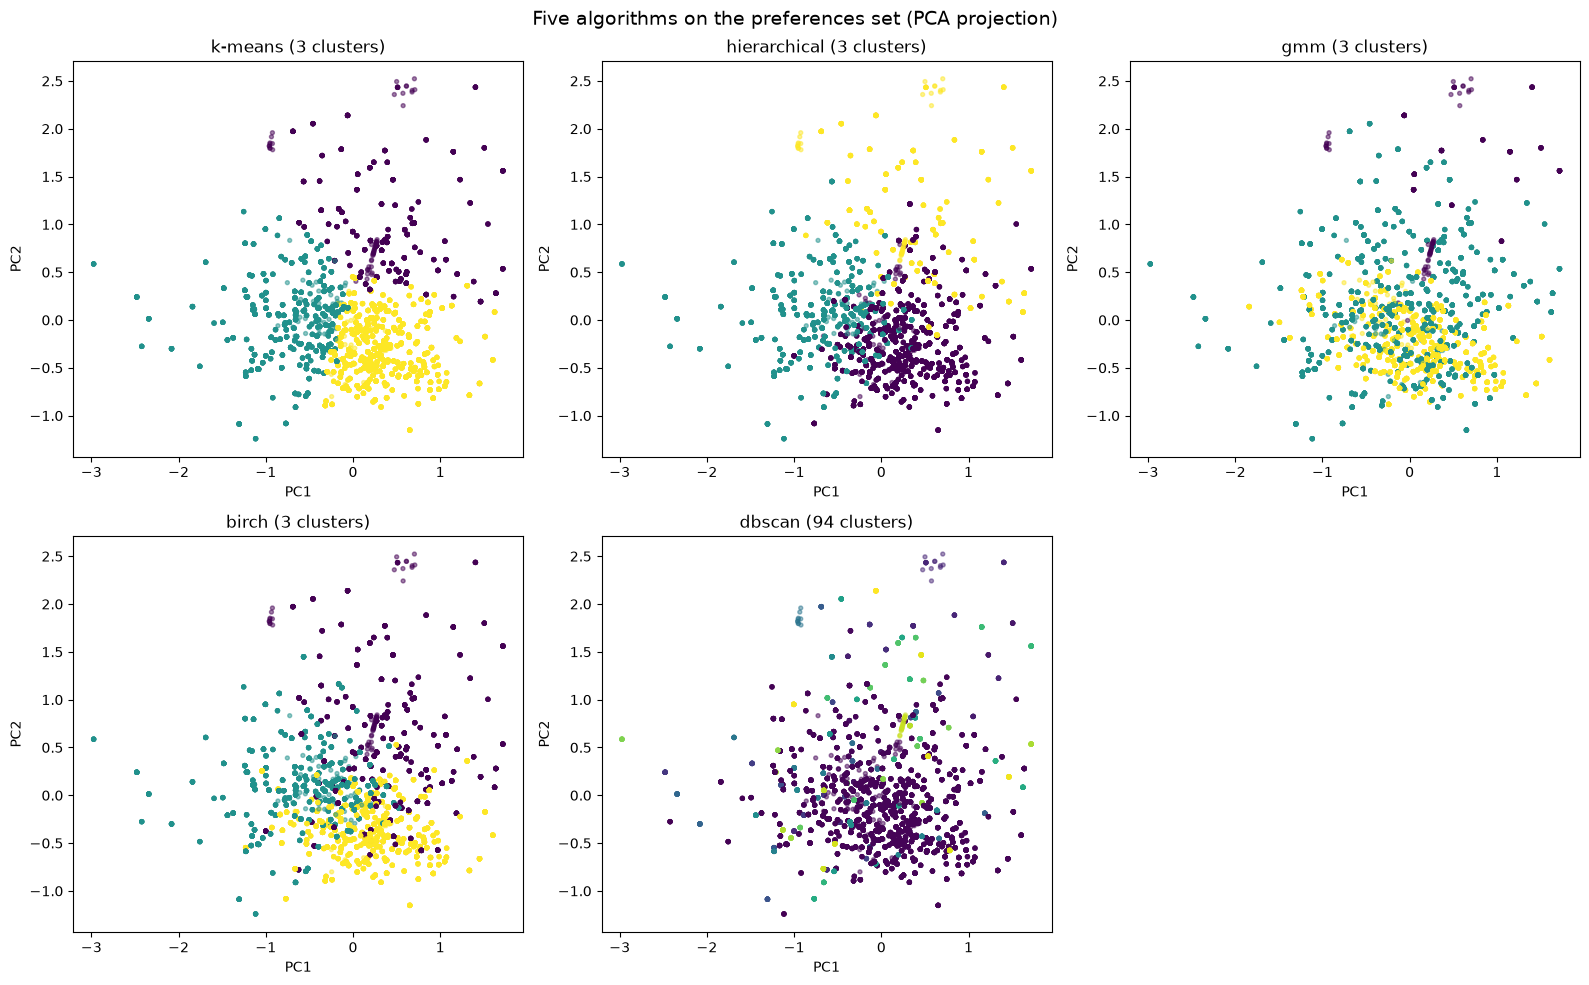

In [29]:
X_pca = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_pref)

plots = [('k-means', km_lbl), ('hierarchical', agg_lbl), ('gmm', gmm_lbl),
         ('birch', birch_lbl), ('dbscan', db_lbl)]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for ax, (name, lbl) in zip(axes, plots):
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=lbl, cmap='viridis', s=8, alpha=0.5)
    n_cl = len(set(lbl)) - (1 if -1 in lbl else 0)
    ax.set_title(f'{name} ({n_cl} clusters)')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
axes[5].axis('off')
plt.suptitle('Five algorithms on the preferences set (PCA projection)', fontsize=14)
plt.tight_layout()
plt.show()

**What the plots show:** k-means and hierarchical produce the same three regions (only
boundaries differ), matching their moderate agreement (ARI ≈ 0.57). GMM's colours are
thoroughly mixed — a visual counterpart to its near-zero silhouette: forcing Gaussian
components onto non-Gaussian data yields no coherent regions. BIRCH keeps a rough three-way
structure but shifts the boundaries (ARI ≈ 0.42). DBSCAN is almost entirely one colour with
scattered specks — its 94 "clusters" are one dominant group plus tiny fragments.

**Takeaway:** k-means and hierarchical agree on the structure; the others diverge, each in a
way explained by its assumptions. No algorithm finds a dramatically better partition than
k-means, which supports using it as the reference model for interpretation.

## Feature set 3: interests only

Using only the 17 hobby attributes. This asks a different question: do people group by how
they spend their free time, independent of gender or preferences? We use k-means here; the
detailed algorithm comparison on the preferences set already established which algorithms suit
this kind of data.

Silhouette by k (interests):
  k=2: silhouette=0.147
  k=3: silhouette=0.099
  k=4: silhouette=0.092
  k=5: silhouette=0.093
  k=6: silhouette=0.084


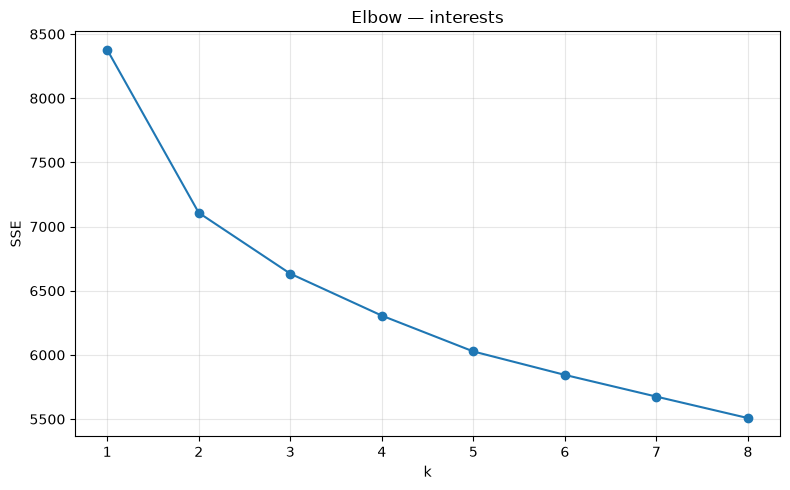

In [30]:
X_int = X_no_outcome[INTERESTS].values
idx = np.random.RandomState(RANDOM_STATE).choice(len(X_int), 2000, replace=False)

print("Silhouette by k (interests):")
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    lbl = km.fit_predict(X_int)
    s = silhouette_score(X_int[idx], lbl[idx])
    print(f"  k={k}: silhouette={s:.3f}")

sse = []
for k in range(1, 9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_int)
    sse.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 9), sse, 'o-')
plt.xlabel('k'); plt.ylabel('SSE'); plt.title('Elbow — interests')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Choosing k:** silhouette peaks clearly at k=2 (0.147), and the elbow bends at k=2. Both
agree — the interests split naturally into two groups.

In [31]:
km_int = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
int_labels = km_int.fit_predict(X_int)

print("Sizes:", pd.Series(int_labels).value_counts().sort_index().tolist())
print("Gender split (share male):")
print(pd.Series(X_no_outcome['gender_male'].values).groupby(int_labels).mean().round(2))
print()

int_profile = pd.DataFrame(index=INTERESTS)
for c in [0, 1]:
    int_profile[f'C{c}'] = X_unscaled.loc[int_labels == c, INTERESTS].mean()
int_profile['overall'] = X_unscaled[INTERESTS].mean()
print(int_profile.round(2))

Sizes: [3671, 4707]
Gender split (share male):
0    0.35
1   -0.27
dtype: float64

           C0   C1  overall
sports   7.09 5.88     6.41
tvsports 4.97 4.25     4.57
exercise 6.35 6.14     6.23
dining   6.95 8.44     7.78
museums  5.47 8.18     6.99
art      4.98 8.09     6.73
hiking   5.08 6.27     5.75
gaming   3.84 3.84     3.84
clubbing 5.29 6.11     5.75
reading  7.03 8.16     7.67
tv       4.86 5.66     5.31
theater  5.26 7.98     6.79
movies   7.11 8.56     7.93
concerts 5.57 7.82     6.83
music    7.10 8.45     7.86
shopping 4.64 6.41     5.64
yoga     3.15 5.29     4.35


In [32]:
interest_names = {0: 'Sporty/casual', 1: 'Cultural/arts'}

for c, name in interest_names.items():
    mask = int_labels == c
    print(f"C{c}: {name} — {mask.sum()} rows, match={meta.loc[mask, 'match'].mean():.3f}")

chi2, p, _, _ = stats.chi2_contingency(pd.crosstab(int_labels, meta['match']))
print(f"\nChi-square: chi2={chi2:.2f}, p={p:.4f}")
print("Significant." if p < 0.05 else "Not significant.")

C0: Sporty/casual — 3671 rows, match=0.153
C1: Cultural/arts — 4707 rows, match=0.174

Chi-square: chi2=5.98, p=0.0145
Significant.


Gender split per interest cluster (share male):
0    0.35
1   -0.27
dtype: float64



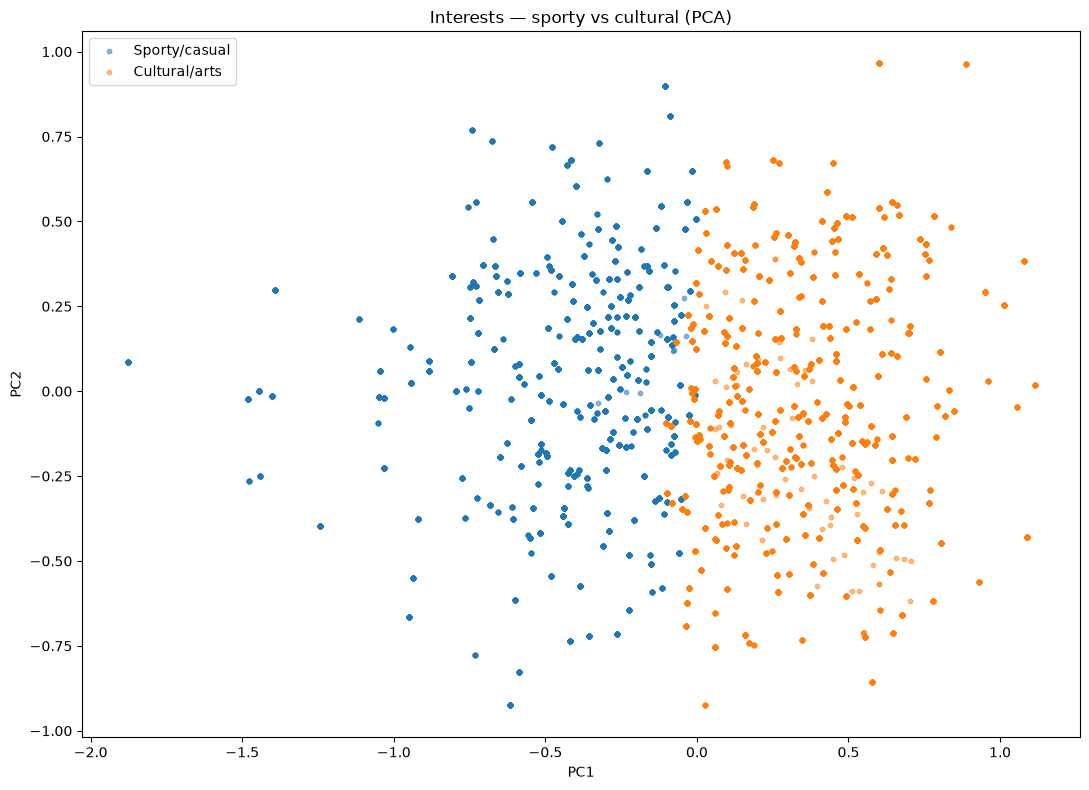

Variance explained: PC1=23.3%, PC2=12.1%

PC1 — one end: {'sports': -0.12, 'tvsports': -0.05, 'exercise': -0.01, 'gaming': 0.01}
PC1 — other end: {'concerts': 0.33, 'theater': 0.38, 'art': 0.39, 'museums': 0.39}

PC2 — one end: {'reading': -0.22, 'museums': -0.12, 'art': -0.11, 'theater': -0.07}
PC2 — other end: {'exercise': 0.33, 'gaming': 0.36, 'sports': 0.46, 'tvsports': 0.52}


In [33]:
print("Gender split per interest cluster (share male):")
print(pd.Series(X_no_outcome['gender_male'].values).groupby(int_labels).mean().round(2))
print()

pca_int = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca_int.fit_transform(X_int)

plt.figure(figsize=(11, 8))
for c in [0, 1]:
    mask = int_labels == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=10, alpha=0.5, label=interest_names[c])
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('Interests — sporty vs cultural (PCA)')
plt.legend()
plt.tight_layout()
plt.show()

loadings = pd.DataFrame(pca_int.components_.T, index=INTERESTS, columns=['PC1', 'PC2'])
print(f"Variance explained: PC1={pca_int.explained_variance_ratio_[0]:.1%}, "
      f"PC2={pca_int.explained_variance_ratio_[1]:.1%}")
print()
print("PC1 — one end:", loadings['PC1'].sort_values().head(4).round(2).to_dict())
print("PC1 — other end:", loadings['PC1'].sort_values().tail(4).round(2).to_dict())
print()
print("PC2 — one end:", loadings['PC2'].sort_values().head(4).round(2).to_dict())
print("PC2 — other end:", loadings['PC2'].sort_values().tail(4).round(2).to_dict())

**Finding:** clustering by interests gives a fundamentally different partition from the person
profile. Instead of splitting by gender, it forms two lifestyle types — sporty and cultural —
each containing both men and women (gender split is mixed: 0.35 and −0.27, not near ±1). These
groups differ significantly in match rate (p ≈ 0.01), with the cultural type matching slightly
more often. This shows that the choice of attributes, not just the algorithm, determines what
structure emerges.

### Interests at k=3

At k=2 the split is sporty vs cultural. Examining k=3 reveals whether a further meaningful
type appears.

In [34]:
km_int3 = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
int_labels3 = km_int3.fit_predict(X_int)

print("Sizes:", pd.Series(int_labels3).value_counts().sort_index().tolist())
print("Gender split (share male):")
print(pd.Series(X_no_outcome['gender_male'].values).groupby(int_labels3).mean().round(2))
print()

int3_profile = pd.DataFrame(index=INTERESTS)
for c in [0, 1, 2]:
    int3_profile[f'C{c}'] = X_unscaled.loc[int_labels3 == c, INTERESTS].mean()
int3_profile['overall'] = X_unscaled[INTERESTS].mean()
print(int3_profile.round(2))

Sizes: [3129, 2908, 2341]
Gender split (share male):
0    0.38
1   -0.31
2   -0.12
dtype: float64

           C0   C1   C2  overall
sports   7.32 4.48 7.59     6.41
tvsports 4.99 2.47 6.61     4.57
exercise 6.48 5.23 7.17     6.23
dining   6.80 8.23 8.53     7.78
museums  5.42 7.96 7.90     6.99
art      4.88 7.93 7.70     6.73
hiking   5.22 5.59 6.65     5.75
gaming   3.85 2.76 5.18     3.84
clubbing 5.19 5.67 6.60     5.75
reading  7.10 8.36 7.56     7.67
tv       4.58 4.96 6.73     5.31
theater  4.98 7.93 7.80     6.79
movies   6.83 8.52 8.66     7.93
concerts 5.42 7.38 8.04     6.83
music    6.96 8.20 8.63     7.86
shopping 4.35 5.96 6.95     5.64
yoga     3.11 4.85 5.37     4.35


In [35]:
interest3_names = {
    0: 'Sports-focused',
    1: 'Culture-focused',
    2: 'Socially active'
}
for c, name in interest3_names.items():
    mask = int_labels3 == c
    print(f"C{c}: {name} — {mask.sum()} rows, match={meta.loc[mask, 'match'].mean():.3f}")

C0: Sports-focused — 3129 rows, match=0.159
C1: Culture-focused — 2908 rows, match=0.164
C2: Socially active — 2341 rows, match=0.173


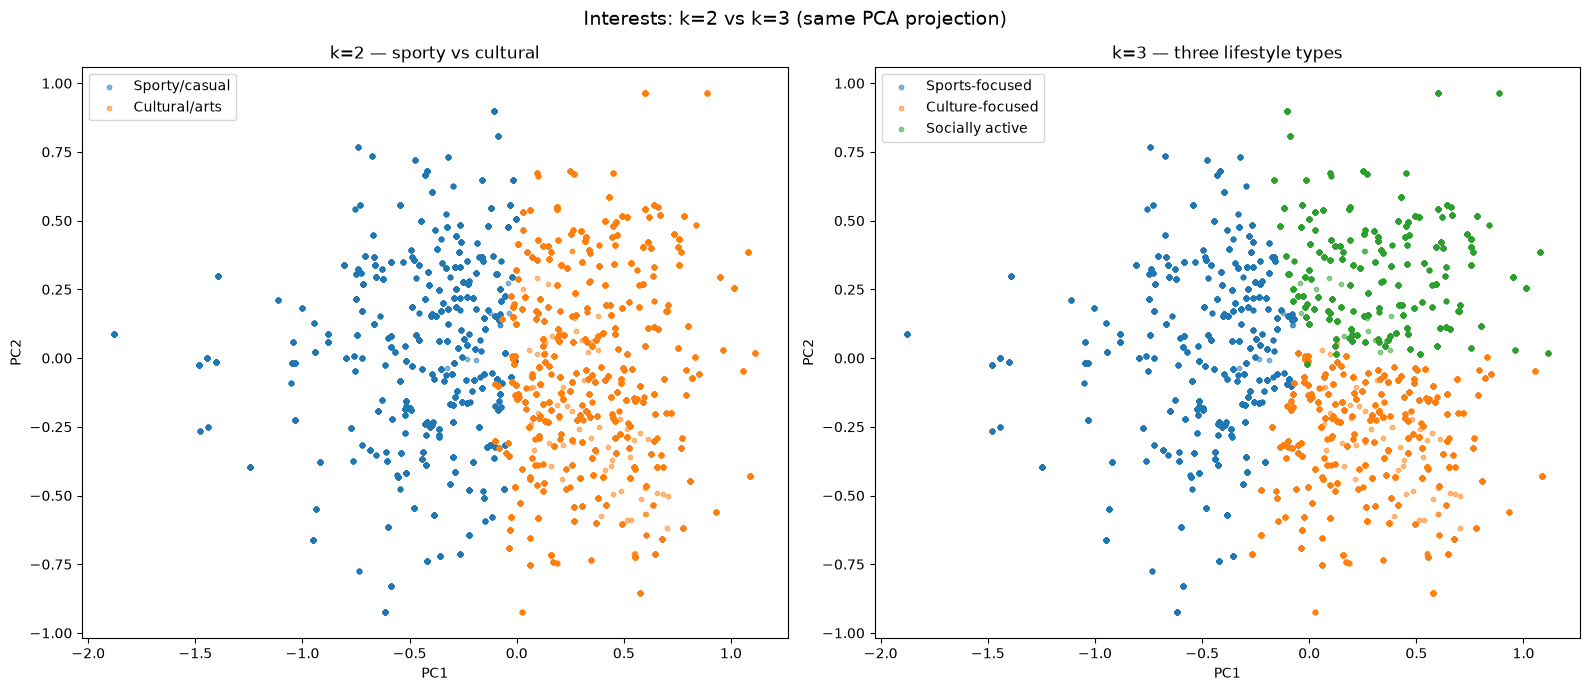

In [36]:
X_int_pca = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_int)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

for c in [0, 1]:
    mask = int_labels == c
    ax1.scatter(X_int_pca[mask, 0], X_int_pca[mask, 1], s=10, alpha=0.5, label=interest_names[c])
ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2')
ax1.set_title('k=2 — sporty vs cultural')
ax1.legend()

for c in [0, 1, 2]:
    mask = int_labels3 == c
    ax2.scatter(X_int_pca[mask, 0], X_int_pca[mask, 1], s=10, alpha=0.5, label=interest3_names[c])
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')
ax2.set_title('k=3 — three lifestyle types')
ax2.legend()

plt.suptitle('Interests: k=2 vs k=3 (same PCA projection)', fontsize=14)
plt.tight_layout()
plt.show()

**Finding:** k=3 reveals a distinct third type. Beyond sporty (C0) and cultural (C1), a
**socially active** type (C2) appears — highest on clubbing, dining, concerts, movies, and
music, the going-out activities. Match rate rises gently across the three (0.159 → 0.164 →
0.173), with the socially active type matching most often — plausibly because comfort in
social settings helps at an event like speed dating.

All three types remain gender-mixed, but not evenly: the share-male values (0.38, −0.31,
−0.12) show the sporty type leans male and the cultural type leans female, while the socially
active type sits near the middle. Interests cross gender, then, but some tilt remains — which
the next analysis quantifies directly.

### How gender-neutral are the interest types?

The interest clusters cross gender, but not perfectly. Here we quantify the actual gender
composition of each type, and identify which individual hobbies are the most gender-linked.

In [37]:
is_male_arr = (X_no_outcome['gender_male'] > 0).values

print("Gender composition per interest type (k=2):")
for c in [0, 1]:
    mask = int_labels == c
    pct_male = is_male_arr[mask].mean() * 100
    print(f"  {interest_names[c]:<16} {pct_male:.0f}% male, {100-pct_male:.0f}% female")

print("\nMost gender-linked hobbies (mean difference, unscaled):")
diffs = {}
for col in INTERESTS:
    diffs[col] = X_unscaled.loc[is_male_arr, col].mean() - X_unscaled.loc[~is_male_arr, col].mean()
diff_s = pd.Series(diffs).sort_values()
print("  More female:", {k: round(v, 2) for k, v in diff_s.head(3).items()})
print("  More male:  ", {k: round(v, 2) for k, v in diff_s.tail(3).items()})

Gender composition per interest type (k=2):
  Sporty/casual    68% male, 32% female
  Cultural/arts    36% male, 64% female

Most gender-linked hobbies (mean difference, unscaled):
  More female: {'shopping': -1.71, 'theater': -1.41, 'yoga': -1.28}
  More male:   {'tvsports': 0.84, 'gaming': 1.12, 'sports': 1.23}


**Finding:** the interest types are genuinely mixed but tilted — the sporty type is 68% male,
the cultural type 64% female. So interests cross gender without erasing it. The tilt comes
from a few strongly gender-linked hobbies: shopping, theater, and yoga lean female, while
sports, gaming, and TV sports lean male. Most other activities (dining, movies, music) are
close to gender-neutral, which is why the clusters mix rather than split cleanly by sex.

## Do interests relate to what people want?

We have two independent clusterings of the same people: by interests (sporty/cultural) and by
preferences (looks/character/ambition). Do they align — for example, do cultural people seek
character, and sporty people seek looks? A cross-tabulation shows whether the two views are
related or independent.

In [38]:
ct = pd.crosstab(
    pd.Series(int_labels).map(interest_names),
    pd.Series(pref_labels).map(pref_names),
    normalize='index'
) * 100

print("Preference type (%) within each interest type:")
print(ct.round(1))
print()

chi2, p, _, _ = stats.chi2_contingency(pd.crosstab(int_labels, pref_labels))
print(f"Chi-square (independence test): chi2={chi2:.2f}, p={p:.4f}")
print("Related — not independent." if p < 0.05 else "Independent.")

Preference type (%) within each interest type:
col_0          Ambition-valuers  Character-seekers  Looks-driven
row_0                                                           
Cultural/arts             58.30              30.30         11.40
Sporty/casual             39.90              38.80         21.20

Chi-square (independence test): chi2=308.14, p=0.0000
Related — not independent.


**Finding:** interests and preferences are strongly related (χ², p < 0.001), not independent.
Cultural people are half as likely to prioritise looks (11% vs 21%) and more likely to value
ambition (58% vs 40%) than sporty people. Lifestyle and partner priorities go together: a
cultural orientation comes with valuing ambition and character over appearance, while the
sporty type is more appearance-open. The two clusterings capture related but distinct facets
of the same underlying disposition.

## Feature set 4: the full profile

In [39]:
X_all = X_full.values
idx = np.random.RandomState(RANDOM_STATE).choice(len(X_all), 2000, replace=False)

print("Silhouette by k (full set):")
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    lbl = km.fit_predict(X_all)
    s = silhouette_score(X_all[idx], lbl[idx])
    print(f"  k={k}: silhouette={s:.3f}")

Silhouette by k (full set):
  k=2: silhouette=0.077
  k=3: silhouette=0.087
  k=4: silhouette=0.082
  k=5: silhouette=0.073
  k=6: silhouette=0.080


In [40]:
km_all = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
all_labels = km_all.fit_predict(X_all)

print("Sizes:", pd.Series(all_labels).value_counts().sort_index().tolist())
print()
print("Gender split (share male):")
print(pd.Series(X_no_outcome['gender_male'].values).groupby(all_labels).mean().round(2))
print()
print("Match rate per cluster:")
print(pd.Series(meta['match'].values).groupby(all_labels).mean().round(3))
print()

check = ['like', 'guess_prob_liked', 'attractive_partner', 'funny_partner',
         'attractive_o', 'funny_o', 'sports', 'art', 'age']
check = [c for c in check if c in X_unscaled.columns]
prof = pd.DataFrame(index=check)
for c in [0, 1, 2]:
    prof[f'C{c}'] = X_unscaled.loc[all_labels == c, check].mean()
prof['overall'] = X_unscaled[check].mean()
print("What defines the clusters (original units):")
print(prof.round(2))

Sizes: [361, 4024, 3993]

Gender split (share male):
0   -0.06
1    1.00
2   -1.00
dtype: float64

Match rate per cluster:
0   0.39
1   0.15
2   0.15
dtype: float64

What defines the clusters (original units):
                      C0    C1    C2  overall
like                7.44  6.22  5.92     6.13
guess_prob_liked    5.93  5.17  5.20     5.22
attractive_partner  7.14  6.42  5.87     6.19
funny_partner       7.70  6.49  6.21     6.41
attractive_o        7.16  5.87  6.42     6.19
funny_o             7.60  6.23  6.47     6.40
sports              6.72  7.02  5.77     6.41
art                 6.51  6.23  7.25     6.73
age                25.26 26.67 26.22    26.40


In [41]:
km_no = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10).fit_predict(X_no_outcome.values)
print(f"ARI (full k=3 vs no-outcome k=3): {adjusted_rand_score(all_labels, km_no):.3f}")

ARI (full k=3 vs no-outcome k=3): 1.000


**Note on expectation:** we expected the outcome proxies to reshape the clusters — perhaps to
dominate them, producing a "successful dates" grouping. The ARI of 1.0 shows this was wrong:
including them changed nothing at all. The structure was already determined by the other
attributes, and `like` / `guess_prob_liked` simply rode along without shifting a single
assignment. A useful reminder to check assumptions against the data rather than trust them.

In [42]:
km_no = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10).fit_predict(X_no_outcome.values)
print("no-outcome sizes:", pd.Series(km_no).value_counts().sort_index().tolist())
print("no-outcome match rate:")
print(pd.Series(meta['match'].values).groupby(km_no).mean().round(3))
print()
print("full sizes:", pd.Series(all_labels).value_counts().sort_index().tolist())

no-outcome sizes: [4025, 3993, 360]
no-outcome match rate:
0   0.15
1   0.15
2   0.39
dtype: float64

full sizes: [361, 4024, 3993]


In [43]:
check = ['attractive_partner', 'funny_partner', 'sincere_partner', 'intelligence_partner',
         'attractive_o', 'funny_o', 'shared_interests_partner', 'shared_interests_o',
         'met', 'samerace', 'age']
check = [c for c in check if c in X_unscaled.columns]

small = pd.Series(all_labels).value_counts().idxmin()
prof = pd.DataFrame(index=check)
prof['small_cluster'] = X_unscaled.loc[all_labels == small, check].mean()
prof['rest'] = X_unscaled.loc[all_labels != small, check].mean()
prof['diff'] = prof['small_cluster'] - prof['rest']
print(f"Small cluster (n={(all_labels==small).sum()}, match=0.39) vs rest:")
print(prof.round(2).sort_values('diff'))

Small cluster (n=361, match=0.39) vs rest:
                          small_cluster  rest  diff
age                               25.26 26.45 -1.19
samerace                           0.42  0.39  0.02
sincere_partner                    7.67  7.15  0.51
intelligence_partner               8.11  7.34  0.77
attractive_partner                 7.14  6.15  0.99
met                                1.00  0.00  1.00
attractive_o                       7.16  6.14  1.01
funny_o                            7.60  6.35  1.25
funny_partner                      7.70  6.35  1.35
shared_interests_o                 6.79  5.43  1.36
shared_interests_partner           6.89  5.43  1.46


In [44]:
print("met value in small cluster vs rest:")
print(f"  small cluster: {X_unscaled.loc[all_labels == small, 'met'].mean():.2f}")
print(f"  rest:          {X_unscaled.loc[all_labels != small, 'met'].mean():.2f}")
print(f"  small cluster size: {(all_labels == small).sum()}, all met=1: "
      f"{(X_unscaled.loc[all_labels == small, 'met'] == 1).all()}")

met value in small cluster vs rest:
  small cluster: 1.00
  rest:          0.00
  small cluster size: 361, all met=1: False


In [45]:
small_met = X_unscaled.loc[all_labels == small, 'met']
print(f"Small cluster met distribution:")
print(small_met.value_counts())
print()
print(f"Exact mean: {small_met.mean():.4f}")
print(f"How many met=1: {(small_met == 1).sum()} of {len(small_met)}")

Small cluster met distribution:
met
1.00    359
0.47      1
0.51      1
Name: count, dtype: int64

Exact mean: 0.9972
How many met=1: 359 of 361


**Finding:** clustering on the full set gives the same partition as the outcome-free set
(ARI = 1.0) — including the outcome proxies changes nothing. Gender still dominates (men vs
women), and a third small cluster of 361 people stands apart.

That cluster is almost entirely `met = 1` (359 of 361) — pairs who had already met before the
event. They rate each other higher on every trait and match at 0.39, more than double the
overall 0.165. This is not a personality type but the effect of a prior acquaintance: people
who already know each other have a large head start in a four-minute date. A single binary
attribute, `met`, carries enough signal to form its own cluster.

Because the full and reduced sets give identical clusters, the outcome proxies added no
structure — which retrospectively justifies excluding them: they were not needed for the
clustering, while keeping match rate an independent check.

In [46]:
joblib.dump(km_women, '../models/kmeans_person_profile.joblib')
joblib.dump(km_int, '../models/kmeans_interests.joblib')
joblib.dump(km_pref, '../models/kmeans_preferences.joblib')

# five-algorithm comparison (preferences)
agg = AgglomerativeClustering(n_clusters=3, linkage='ward').fit(X_pref)
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=RANDOM_STATE).fit(X_pref)
birch = Birch(n_clusters=3, threshold=0.2).fit(X_pref)
joblib.dump(agg, '../models/pref_hierarchical.joblib')
joblib.dump(gmm, '../models/pref_gmm.joblib')
joblib.dump(birch, '../models/pref_birch.joblib')

labels_df = meta[['row_id', 'person_id', 'wave', 'match']].copy()
labels_df['person_cluster'] = final_labels
labels_df['interest_cluster'] = int_labels
labels_df['preference_cluster'] = pref_labels
labels_df.to_csv('../data/processed/cluster_labels.csv', index=False)

print("Saved main models, comparison models, and labels.")

Saved main models, comparison models, and labels.


## Synthesis

Clustering the same 8378 participants under different feature sets produced fundamentally
different structures — the choice of attributes mattered more than the choice of algorithm.

- **Person profile** splits by gender, then into three types (one male, two female). These
  differ significantly in match rate (p ≈ 0.003).
- **Interests** split by lifestyle — sporty, cultural, and (at k=3) socially active — crossing
  gender, though with a tilt (sporty 68% male, cultural 64% female). These also differ in match
  rate (p ≈ 0.01).
- **Preferences** split by what people value — looks, character, ambition — but do **not**
  differ in match rate (p ≈ 0.17).
- **Full set** reproduces the person-profile clusters exactly (ARI = 1.0); the outcome proxies
  added nothing. A separate small cluster emerged, defined almost entirely by `met` — pairs who
  had met before, matching at more than double the overall rate.

Interests and preferences are themselves related (p < 0.001): cultural people value ambition
and character over looks. The feature sets capture related but distinct facets of the same
people.

On the preferences set, five algorithms were compared in detail. k-means and hierarchical were
the most stable and interpretable; GMM succeeded only where structure was near-Gaussian; DBSCAN
was unsuited throughout, as the data has no density gaps. A recurring caution: silhouette must
be read alongside cluster sizes, since a degenerate partition (a giant cluster plus a few
outliers) can score deceptively high.

Throughout, clustering used the outcome-free feature set, so match rate stayed an independent
check. The clearest finding: in this sample, **who a person is** — profile and lifestyle —
relates to matching success, while **what they say they want** does not.